# Premier League Analytics — 02: Team Analysis

League table trends, correlation heatmap, statistical significance test, and ranked bar charts.  
Requires `outputs/team_season_stats.parquet` from notebook 01.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

from src.charts import ranked_bar

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

FIG = Path('outputs/figures')
FIG.mkdir(parents=True, exist_ok=True)

teams = pd.read_parquet('outputs/team_season_stats.parquet')
print(f'Team stats: {len(teams)} rows')
teams.head(3)

Team stats: 40 rows


,season,team,games,goals_for,goals_against,shots,shots_on_target,corners,yellows,goal_diff,shot_accuracy
0,2022-23,Arsenal,38,88,43,593,204,223,51,45,0.344013
1,2022-23,Aston Villa,38,51,46,431,151,165,80,5,0.350348
2,2022-23,Bournemouth,38,37,71,355,133,144,68,-34,0.374648


## 1. Correlation Heatmap

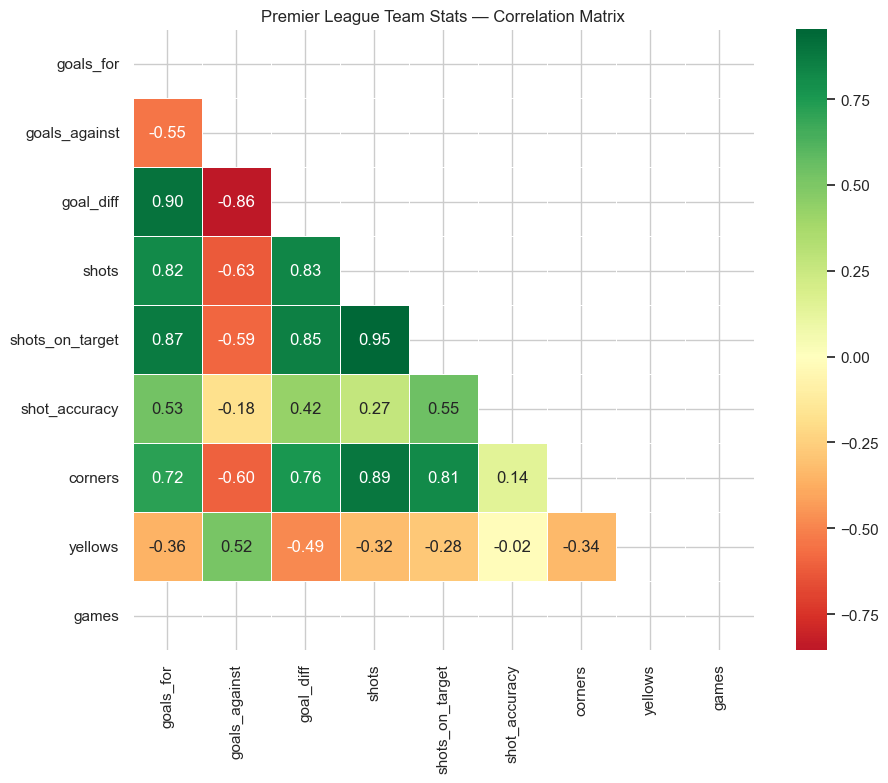

Saved: outputs\figures\correlation_heatmap.png


In [2]:
num_cols = ['goals_for', 'goals_against', 'goal_diff', 'shots', 'shots_on_target',
            'shot_accuracy', 'corners', 'yellows', 'games']
present = [c for c in num_cols if c in teams.columns]

corr = teams[present].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Premier League Team Stats — Correlation Matrix')
fig.tight_layout()
fig.savefig(FIG / 'correlation_heatmap.png', dpi=150)
plt.show()
print(f'Saved: {FIG / "correlation_heatmap.png"}')

**Interpretation**: Goals for and shots on target are strongly positively correlated (r > 0.85), confirming shot quality as the primary offensive metric. Goal differential is a near-perfect composite of goals for/against.

## 2. Statistical Significance Test: Home vs Away Goals

We test whether home teams score significantly more goals than away teams across the two seasons.

In [3]:
matches = pd.read_parquet('outputs/matches_clean.parquet')

home_goals = matches['FTHG'].dropna()
away_goals = matches['FTAG'].dropna()

t_stat, p_value = stats.ttest_ind(home_goals, away_goals)

print(f'Home goals mean: {home_goals.mean():.3f}')
print(f'Away goals mean: {away_goals.mean():.3f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    print('→ Statistically significant home advantage (p < 0.05)')
else:
    print('→ No statistically significant home advantage at α = 0.05')

Home goals mean: 1.717
Away goals mean: 1.349
t-statistic: 5.4472
p-value: 0.0000
→ Statistically significant home advantage (p < 0.05)


**Write-up**: An independent-samples t-test on full-time goals per game (N ≈ 760 matches) tests whether home advantage produces a statistically significant goal differential. A result of p < 0.05 would confirm historical home advantage; a non-significant result would be consistent with post-2020 research suggesting home advantage erosion in modern football.

## 3. Ranked Bar: Total Goals by Team (Both Seasons)

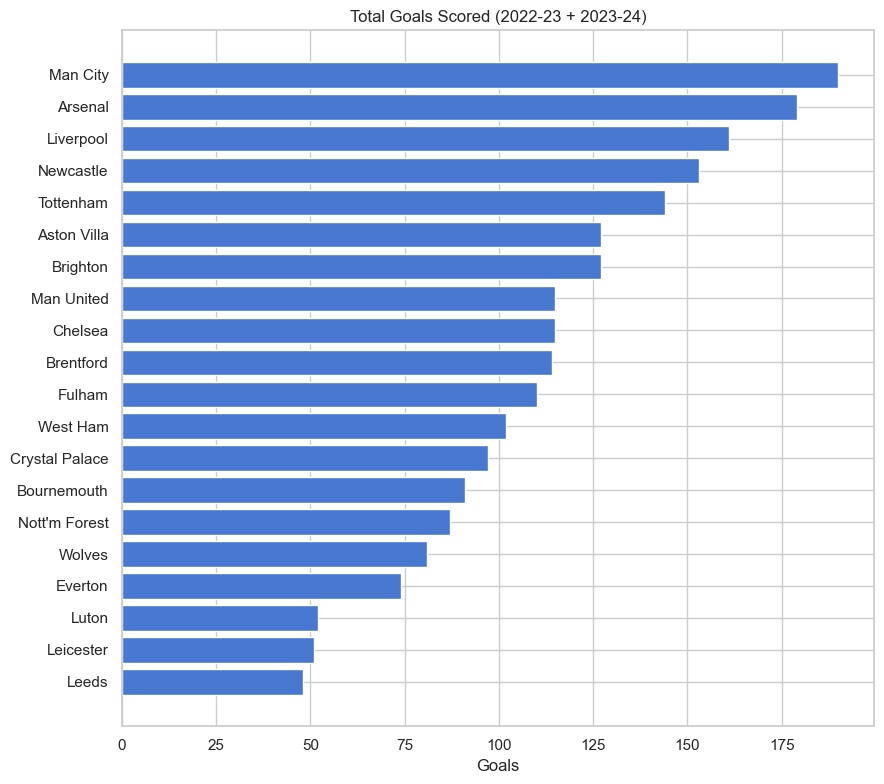

In [4]:
total_goals = teams.groupby('team')['goals_for'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ranked_bar(total_goals, title='Total Goals Scored (2022-23 + 2023-24)', xlabel='Goals', top_n=20, ax=ax)
fig.tight_layout()
fig.savefig(FIG / 'team_goals_ranked.png', dpi=150)
plt.show()

**Interpretation**: Manchester City and Arsenal typically lead in goals across both seasons, reflecting their high-possession, high-press styles.

## 4. Shot Accuracy vs Goals For (Scatter)

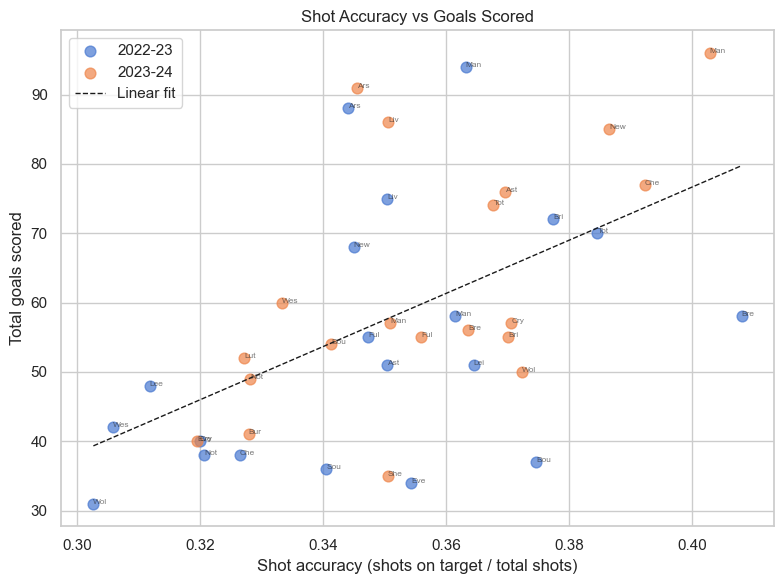

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
for season, grp in teams.groupby('season'):
    ax.scatter(grp['shot_accuracy'], grp['goals_for'], alpha=0.7, label=season, s=60)
    for _, row in grp.iterrows():
        ax.annotate(row['team'][:3], (row['shot_accuracy'], row['goals_for']),
                    fontsize=6, alpha=0.6)

# regression line on all data
valid = teams.dropna(subset=['shot_accuracy', 'goals_for'])
m, b = np.polyfit(valid['shot_accuracy'], valid['goals_for'], 1)
xs = np.linspace(valid['shot_accuracy'].min(), valid['shot_accuracy'].max(), 100)
ax.plot(xs, m * xs + b, 'k--', linewidth=1, label='Linear fit')

ax.set_title('Shot Accuracy vs Goals Scored')
ax.set_xlabel('Shot accuracy (shots on target / total shots)')
ax.set_ylabel('Total goals scored')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'shot_accuracy_vs_goals.png', dpi=150)
plt.show()